In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)

2026-06-07 07:10:36.395857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780816236.613363      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780816236.675363      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780816237.190785      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780816237.190822      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780816237.190825      23 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
train_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train"

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


In [5]:
print(train_generator.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


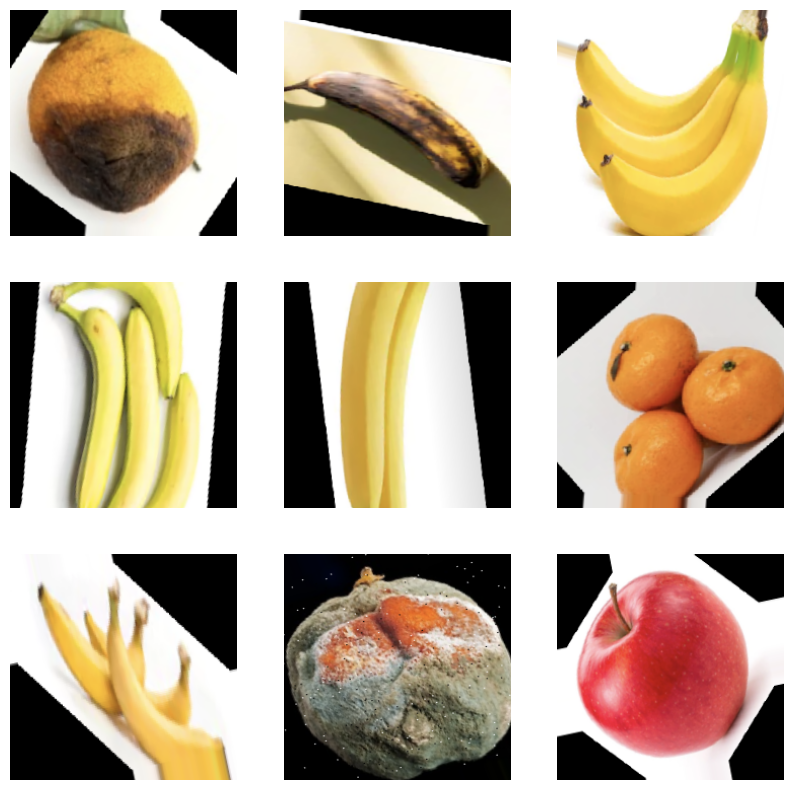

In [6]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [7]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')

])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780816254.857815      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780816254.863759      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train"

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"


In [9]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15


I0000 00:00:1780816259.679600      92 service.cc:152] XLA service 0x7a6bcc0046f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780816259.679675      92 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780816259.679682      92 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780816260.158364      92 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-07 07:11:02.831187: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 07:11:02.979547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/273 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.1875 - loss: 2.9959

I0000 00:00:1780816266.058454      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


273/273 ━━━━━━━━━━━━━━━━━━━━ 208s 733ms/step - accuracy: 0.6750 - loss: 0.8681 - val_accuracy: 0.8636 - val_loss: 0.4040
Epoch 2/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 142s 519ms/step - accuracy: 0.8519 - loss: 0.4321 - val_accuracy: 0.8609 - val_loss: 0.4098
Epoch 3/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 141s 517ms/step - accuracy: 0.8726 - loss: 0.3561 - val_accuracy: 0.9169 - val_loss: 0.2293
Epoch 4/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 139s 511ms/step - accuracy: 0.8919 - loss: 0.2962 - val_accuracy: 0.9302 - val_loss: 0.1906
Epoch 5/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 513ms/step - accuracy: 0.9035 - loss: 0.2587 - val_accuracy: 0.9389 - val_loss: 0.1736
Epoch 6/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 139s 511ms/step - accuracy: 0.9122 - loss: 0.2468 - val_accuracy: 0.9454 - val_loss: 0.1549
Epoch 7/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 511ms/step - accuracy: 0.9172 - loss: 0.2274 - val_accuracy: 0.9518 - val_loss: 0.1337
Epoch 8/15
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 514ms/step - accuracy: 0.9250 - loss: 0.20

In [11]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("CNN Test Accuracy:", test_acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 27s 318ms/step - accuracy: 0.9759 - loss: 0.0664
CNN Test Accuracy: 0.975908100605011


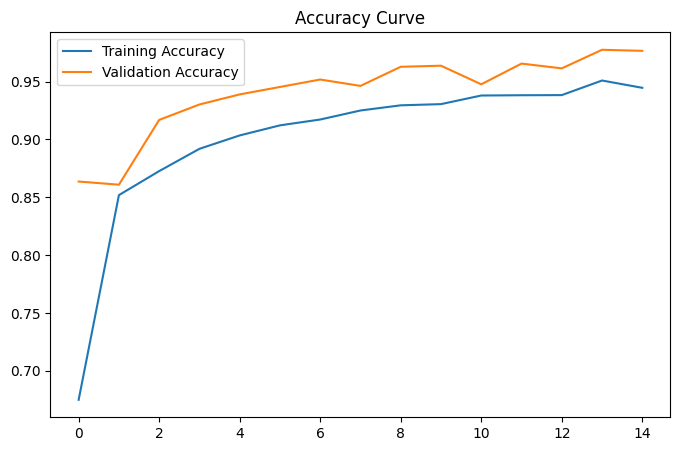

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Curve")
plt.show()

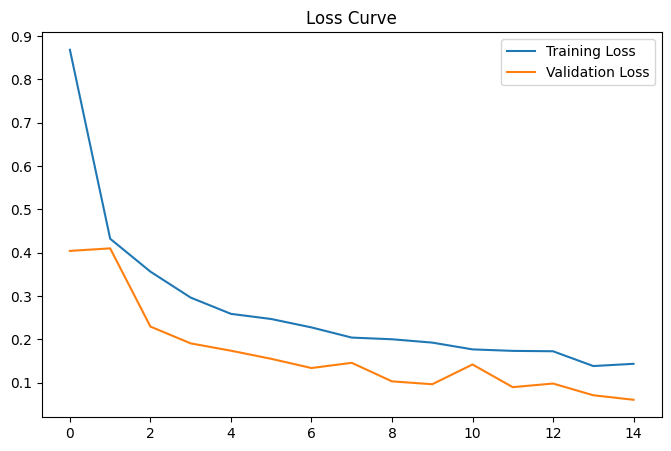

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.legend()
plt.title("Loss Curve")
plt.show()

In [14]:
predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step


In [15]:
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

  freshapples       0.96      0.98      0.97       395
  freshbanana       1.00      0.99      1.00       381
 freshoranges       0.98      0.95      0.97       388
 rottenapples       0.94      0.97      0.96       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.98      0.96      0.97       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



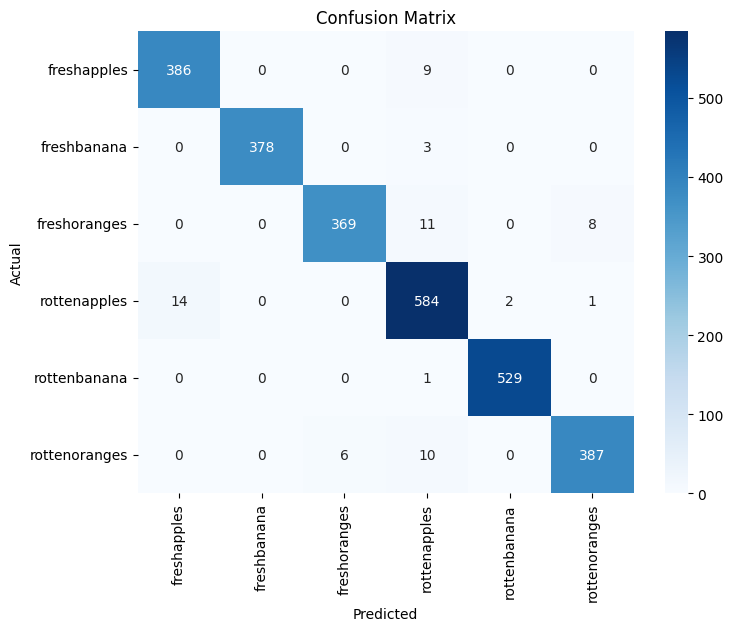

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("CNN Test Accuracy:", test_acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - accuracy: 0.9759 - loss: 0.0664
CNN Test Accuracy: 0.975908100605011


In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

  freshapples       0.96      0.98      0.97       395
  freshbanana       1.00      0.99      1.00       381
 freshoranges       0.98      0.95      0.97       388
 rottenapples       0.94      0.97      0.96       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.98      0.96      0.97       403

     accuracy                           0.98      2698
    macro avg       0.98      0.98      0.98      2698
 weighted avg       0.98      0.98      0.98      2698



In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(
    6,
    activation='softmax'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [22]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


2026-06-07 07:48:24.258111: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 07:48:24.405558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 07:48:24.542687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


137/273 ━━━━━━━━━━━━━━━━━━━━ 54s 404ms/step - accuracy: 0.8345 - loss: 0.4729

2026-06-07 07:49:30.043709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 07:49:30.190761: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 07:49:30.328113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8844 - loss: 0.3311

2026-06-07 07:51:09.906938: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 07:51:10.044929: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


273/273 ━━━━━━━━━━━━━━━━━━━━ 182s 607ms/step - accuracy: 0.9430 - loss: 0.1627 - val_accuracy: 0.9885 - val_loss: 0.0369
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 141s 517ms/step - accuracy: 0.9844 - loss: 0.0478 - val_accuracy: 0.9940 - val_loss: 0.0199
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 141s 517ms/step - accuracy: 0.9841 - loss: 0.0464 - val_accuracy: 0.9963 - val_loss: 0.0126
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 511ms/step - accuracy: 0.9904 - loss: 0.0252 - val_accuracy: 0.9784 - val_loss: 0.0516
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 512ms/step - accuracy: 0.9907 - loss: 0.0273 - val_accuracy: 0.9913 - val_loss: 0.0284
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 513ms/step - accuracy: 0.9897 - loss: 0.0271 - val_accuracy: 0.9982 - val_loss: 0.0080
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 511ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9982 - val_loss: 0.0080
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 139s 509ms/step - accuracy: 0.9932 - loss: 0.01

In [24]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Accuracy:", mobile_acc)

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9941 - loss: 0.0194

2026-06-07 08:12:36.905502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 08:12:37.042274: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - accuracy: 0.9893 - loss: 0.0383
MobileNetV2 Accuracy: 0.9892513155937195


NameError: name 'cnn_model' is not defined